# EDA — Disaster TweetsInspect the raw Kaggle data, decide what to do about missing values, and checkwhich columns actually carry signal. Writes the null-filled frames to`DATA/Clean/` for `text_preprocessing.ipynb` to pick up.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve the repo root whether the kernel starts in notebook/ or the repo root,
# so the paths below survive being run from either place.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

RAW = PROJECT_ROOT / "DATA" / "Raw"
CLEAN = PROJECT_ROOT / "DATA" / "Clean"
CLEAN.mkdir(parents=True, exist_ok=True)
print(PROJECT_ROOT)

/mnt/d/NLP-Starter/NLP_Starter-Disaster-Tweet


In [2]:
df_train = pd.read_csv(RAW / "train.csv")
df_test = pd.read_csv(RAW / "test.csv")
df_train.shape, df_test.shape

((7613, 5), (3263, 4))

In [3]:
df_train.dtypes

id           int64
keyword     object
location    object
text        object
target       int64
dtype: object

## Target distribution

target
0    4342
1    3271
Name: count, dtype: int64
target
0    0.5703
1    0.4297
Name: proportion, dtype: float64


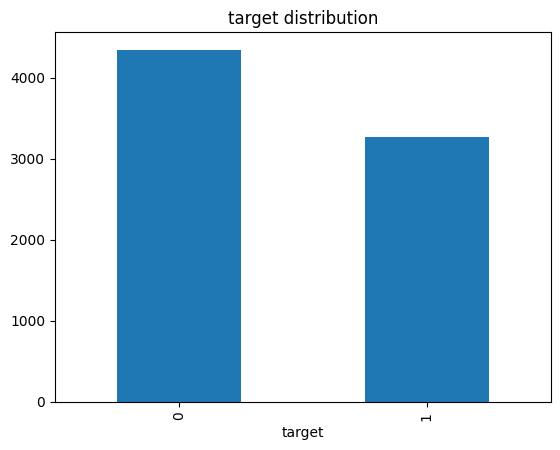

In [4]:
print(df_train["target"].value_counts())
print(df_train["target"].value_counts(normalize=True).round(4))
df_train["target"].value_counts().plot(kind="bar", title="target distribution")
plt.show()

~59/41. Mild enough to skip class weights or resampling, but report F1 alongsideaccuracy rather than trusting accuracy alone.

## Missing values

In [5]:
df_train.isna().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

In [6]:
# Each frame is measured against its OWN row count.
missing = pd.DataFrame({
    "train_%": df_train.isna().mean() * 100,
    "test_%": df_test.isna().mean() * 100,
}).round(2)
missing

,train_%,test_%
id,0.00,0.00
keyword,0.80,0.80
location,33.27,33.86
target,0.00,NaN
text,0.00,0.00


`location` is a third missing in both frames; `keyword` is under 1%.

In [7]:
for df in (df_train, df_test):
    df["keyword"] = df["keyword"].fillna("missing")
    # Two location values carry an embedded newline, which turns the saved CSV
    # into quoted multi-line records. Collapse whitespace before filling.
    df["location"] = (df["location"].fillna("no_location")
                      .str.replace(r"\s+", " ", regex=True).str.strip())

print(df_train.isna().sum().sum(), df_test.isna().sum().sum())

0 0


## `keyword` — the strongest cheap feature222 values, and every keyword in test also appears in train, so it can be useddirectly without an unseen-category problem.

In [8]:
# Values arrive URL-encoded: 'body%20bags', 'airplane%20accident'.
encoded = [k for k in df_train["keyword"].unique() if "%" in k]
print(f"{len(encoded)} of {df_train['keyword'].nunique()} keywords are URL-encoded")
print(encoded[:6])

36 of 222 keywords are URL-encoded
['airplane%20accident', 'blew%20up', 'blown%20up', 'body%20bag', 'body%20bagging', 'body%20bags']


In [9]:
from src.text_cleaner import clean_keyword

for df in (df_train, df_test):
    df["keyword"] = df["keyword"].apply(clean_keyword)

print(df_train["keyword"].nunique(), "distinct keywords")
print("test keywords unseen in train:",
      len(set(df_test["keyword"]) - set(df_train["keyword"])))

222 distinct keywords
test keywords unseen in train: 0


In [10]:
kw = (df_train.groupby("keyword")["target"]
      .agg(disaster_rate="mean", n="count")
      .query("n >= 20")
      .sort_values("disaster_rate"))

print("--- least disaster-y ---")
print(kw.head(8).round(3))
print("\n--- most disaster-y ---")
print(kw.tail(8).round(3))

--- least disaster-y ---
             disaster_rate   n
keyword                       
aftershock           0.000  34
body bags            0.024  41
ruin                 0.027  37
blazing              0.029  34
body bag             0.030  33
electrocute          0.031  32
screaming            0.056  36
traumatised          0.057  35

--- most disaster-y ---
                 disaster_rate   n
keyword                           
suicide bomber           0.968  31
suicide bombing          0.970  33
oil spill                0.974  38
typhoon                  0.974  38
outbreak                 0.975  40
derailment               1.000  39
debris                   1.000  37
wreckage                 1.000  39


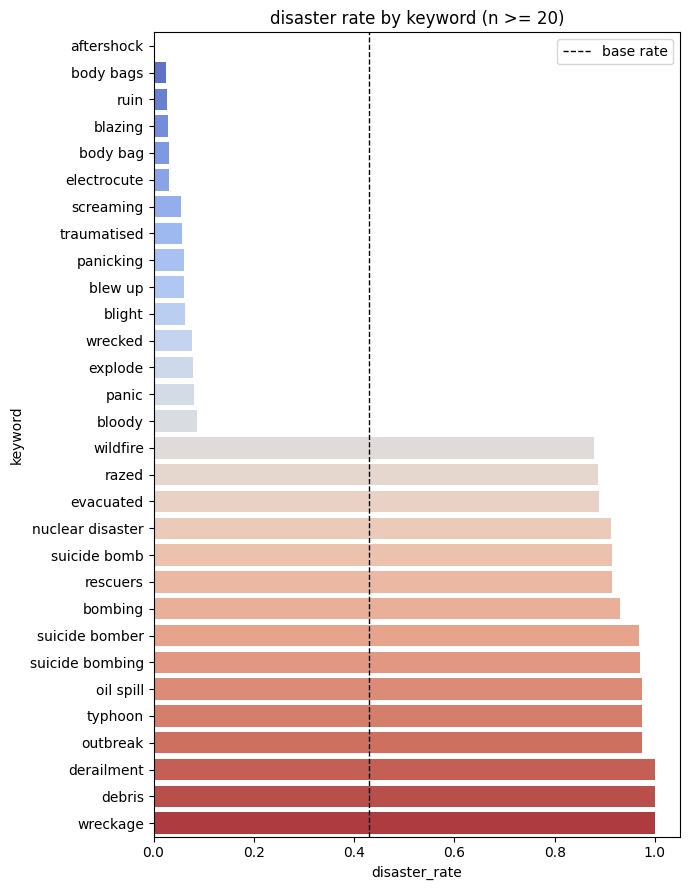

In [11]:
extremes = pd.concat([kw.head(15), kw.tail(15)])
plt.figure(figsize=(7, 9))
sns.barplot(x="disaster_rate", y=extremes.index, hue=extremes.index,
            data=extremes, palette="coolwarm", legend=False)
plt.axvline(df_train["target"].mean(), ls="--", c="k", lw=1, label="base rate")
plt.title("disaster rate by keyword (n >= 20)")
plt.legend()
plt.tight_layout()
plt.show()

Several keywords are perfectly separating (`derailment`, `debris`, `wreckage` at1.00; `aftershock` at 0.00) against a 0.41 base rate. Worth feeding to the modelas a categorical feature or prepending to the text.

## `location` — high cardinality, low value

In [12]:
loc = df_train["location"]
present = loc[loc != "no_location"]
vc = present.value_counts()

print("distinct values          :", loc.nunique())
print("filled as 'no_location'  :", int((loc == 'no_location').sum()))
print("values appearing exactly once: %d (%.1f%% of distinct)"
      % ((vc == 1).sum(), (vc == 1).mean() * 100))
print("test locations unseen in train:",
      len(set(df_test['location']) - set(df_train['location'])),
      "of", df_test['location'].nunique())
print()
print(vc.head(8))

distinct values          : 3278
filled as 'no_location'  : 2533
values appearing exactly once: 2743 (83.7% of distinct)
test locations unseen in train: 1154 of 1586

location
USA                105
New York            73
United States       50
London              46
Nigeria             32
Canada              30
UK                  27
Los Angeles, CA     26
Name: count, dtype: int64


Free text: 84% of the non-null values occur once, and most test locations neverappear in train. Filling it makes the column look usable when it is not — treat`location` as unusable unless it is geocoded/normalised first.

## Text — duplicates and length

exact duplicate texts: 110
count    7613.00
mean       14.90
std         5.73
min         1.00
25%        11.00
50%        15.00
75%        19.00
max        31.00
Name: text, dtype: float64

95th/99th percentile: [24.0, 27.0]


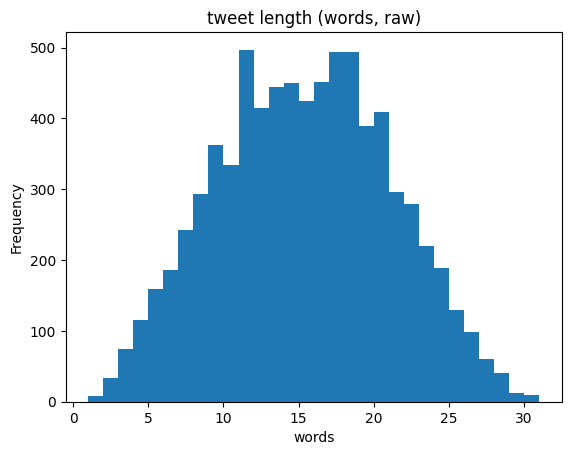

In [13]:
print("exact duplicate texts:", int(df_train.duplicated(subset=['text']).sum()))

lengths = df_train["text"].str.split().str.len()
print(lengths.describe().round(2))
print("\n95th/99th percentile:", lengths.quantile([.95, .99]).round(1).tolist())

lengths.plot(kind="hist", bins=30, title="tweet length (words, raw)")
plt.xlabel("words")
plt.show()

## Encoding artifactsThe raw text is mojibake-corrupted and carries un-escaped HTML entities. Bothwould survive naive regex cleaning and become junk vocabulary, which is why`src/text_cleaner.py` repairs them before anything else runs.

In [14]:
import re

both = pd.concat([df_train["text"], df_test["text"]])
for label, pat in [("mojibake 'Û'", "Û"), ("mojibake 'å'", "å"), ("mojibake 'Ì'", "Ì"),
                   ("&amp;", "&amp;"), ("&lt;/&gt;", "&lt;"), ("embedded newline", "\n")]:
    print(f"{label:20} {int(both.str.contains(re.escape(pat), regex=True).sum()):5} rows")

runs = pd.Series([m for s in both for m in re.findall(r"[^\x00-\x7F]+", s)])
print("\ndistinct non-ascii runs:", runs.nunique(), "| occurrences:", len(runs))
print(runs.value_counts().head(8))

mojibake 'Û'           898 rows
mojibake 'å'           120 rows
mojibake 'Ì'            40 rows
&amp;                  447 rows
&lt;/&gt;               25 rows
embedded newline       645 rows

distinct non-ascii runs: 47 | occurrences: 1330
Û     523
Ûª    272
ÛÏ     94
åÊ      81
ÛÒ     74
Û÷     62
Û     59
ÛÓ     55
Name: count, dtype: int64


## SaveNull-filled and keyword-decoded, but the tweet text is still **raw** here — textcleaning happens in `text_preprocessing.ipynb` via `src/text_cleaner.py`.

In [15]:
df_train.to_csv(CLEAN / "cleaned_train_data.csv", index=False)
df_test.to_csv(CLEAN / "cleaned_test_data.csv", index=False)
print("wrote", CLEAN / "cleaned_train_data.csv")
print("wrote", CLEAN / "cleaned_test_data.csv")

wrote /mnt/d/NLP-Starter/NLP_Starter-Disaster-Tweet/DATA/Clean/cleaned_train_data.csv
wrote /mnt/d/NLP-Starter/NLP_Starter-Disaster-Tweet/DATA/Clean/cleaned_test_data.csv
